<a href="https://colab.research.google.com/github/polinasunko24-cmd/portfolio_python/blob/main/%D0%AD%D0%BA%D1%81%D0%BF%D0%B5%D1%80%D0%B8%D0%BC%D0%B5%D0%BD%D1%82.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('/content/data_raw_push.csv')

In [5]:
df.head()

,dt,user_id,ab_group,event_type,value
0,2025-05-02 16:27:02,8000,A_short,push_sent,NaN
1,2025-05-02 13:06:16,8001,B_long,push_sent,NaN
2,2025-05-01 21:31:14,8002,B_long,push_sent,NaN
3,2025-05-03 15:53:34,8003,B_long,push_sent,NaN
4,2025-05-02 04:54:38,8004,B_long,push_sent,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 402 entries, 0 to 401
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   dt          402 non-null    object 
 1   user_id     402 non-null    int64  
 2   ab_group    402 non-null    object 
 3   event_type  402 non-null    object 
 4   value       52 non-null     float64
dtypes: float64(1), int64(1), object(3)
memory usage: 15.8+ KB


In [7]:
df['event_type'].value_counts()

,count
event_type,
push_sent,220
push_opened,59
article_viewed,52
read_time,52
session_continued,19


In [8]:
df['dt'] = pd.to_datetime(df['dt'])
df['date'] = df['dt'].dt.date

In [9]:
df[['dt', 'date']].head()

,dt,date
0,2025-05-02 16:27:02,2025-05-02
1,2025-05-02 13:06:16,2025-05-02
2,2025-05-01 21:31:14,2025-05-01
3,2025-05-03 15:53:34,2025-05-03
4,2025-05-02 04:54:38,2025-05-02


In [10]:
df.groupby(['date', 'user_id', 'event_type']).size().sort_values(ascending=False).head(10)

date        user_id  event_type    
2025-05-03  8219     push_sent         1
2025-05-01  8002     push_sent         1
2025-05-03  8196     article_viewed    1
            8195     push_sent         1
            8192     push_opened       1
            8190     push_opened       1
                     article_viewed    1
            8188     push_sent         1
            8186     read_time         1
                     push_sent         1
dtype: int64

In [23]:
funnel = (
    df[df['event_type'] != 'read_time']
    .pivot_table(
        index=['date', 'user_id', 'ab_group'],
        columns='event_type',
        values='dt',
        aggfunc='count',
        fill_value=0
    )
    .reset_index()
)

funnel.head()

event_type,date,user_id,ab_group,article_viewed,push_opened,push_sent,session_continued
0,2025-05-01,8002,B_long,0,0,1,0
1,2025-05-01,8006,B_long,1,0,0,0
2,2025-05-01,8014,B_long,0,0,0,1
3,2025-05-01,8017,B_long,1,0,0,0
4,2025-05-01,8018,B_long,1,0,0,0


In [12]:
read_time = df[df['event_type'] == 'read_time'][
    ['date', 'user_id', 'ab_group', 'value']
].copy()

read_time.head()

,date,user_id,ab_group,value
9,2025-05-02,8006,B_long,175.0
14,2025-05-02,8008,B_long,126.0
23,2025-05-03,8014,B_long,176.0
28,2025-05-03,8015,A_short,275.0
34,2025-05-01,8017,B_long,177.0


In [13]:
read_time = read_time.rename(columns={'value': 'read_time'})

In [14]:
read_time.head()

,date,user_id,ab_group,read_time
9,2025-05-02,8006,B_long,175.0
14,2025-05-02,8008,B_long,126.0
23,2025-05-03,8014,B_long,176.0
28,2025-05-03,8015,A_short,275.0
34,2025-05-01,8017,B_long,177.0


In [15]:
funnel = funnel.merge(
    read_time,
    on=['date', 'user_id', 'ab_group'],
    how='left'
)

funnel.head()

,date,user_id,ab_group,article_viewed,push_opened,push_sent,session_continued,read_time
0,2025-05-01,8002,B_long,0,0,1,0,NaN
1,2025-05-01,8006,B_long,1,0,0,0,NaN
2,2025-05-01,8014,B_long,0,0,0,1,NaN
3,2025-05-01,8017,B_long,1,0,0,0,177.0
4,2025-05-01,8018,B_long,1,0,0,0,193.0


In [16]:
len(read_time), funnel['read_time'].notna().sum()

(52, np.int64(39))

In [24]:
funnel = funnel.merge(
    read_time,
    on=['date', 'user_id', 'ab_group'],
    how='outer'
)

In [25]:
len(read_time), funnel['read_time'].notna().sum()

(52, np.int64(52))

In [26]:
funnel.isna().sum()

,0
date,0
user_id,0
ab_group,0
article_viewed,13
push_opened,13
push_sent,13
session_continued,13
read_time,245


In [27]:
event_cols = ['push_sent', 'push_opened', 'article_viewed', 'session_continued']

funnel[event_cols] = funnel[event_cols].fillna(0)

In [28]:
funnel.isna().sum()

,0
date,0
user_id,0
ab_group,0
article_viewed,0
push_opened,0
push_sent,0
session_continued,0
read_time,245


In [29]:
funnel = funnel[
    [
        'date',
        'user_id',
        'ab_group',
        'push_sent',
        'push_opened',
        'article_viewed',
        'read_time',
        'session_continued'
    ]
]

funnel.head(10)

,date,user_id,ab_group,push_sent,push_opened,article_viewed,read_time,session_continued
0,2025-05-01,8002,B_long,1.0,0.0,0.0,NaN,0.0
1,2025-05-01,8006,B_long,0.0,0.0,1.0,NaN,0.0
2,2025-05-01,8014,B_long,0.0,0.0,0.0,NaN,1.0
3,2025-05-01,8017,B_long,0.0,0.0,1.0,177.0,0.0
4,2025-05-01,8018,B_long,0.0,0.0,1.0,193.0,0.0
5,2025-05-01,8019,B_long,1.0,0.0,0.0,NaN,0.0
6,2025-05-01,8020,A_short,1.0,0.0,1.0,67.0,0.0
7,2025-05-01,8023,B_long,0.0,1.0,1.0,NaN,0.0
8,2025-05-01,8024,B_long,1.0,0.0,0.0,NaN,0.0
9,2025-05-01,8026,B_long,0.0,1.0,0.0,NaN,0.0


In [30]:
user_metrics = (
    funnel
    .groupby(['user_id', 'ab_group'], as_index=False)
    .agg({
        'push_sent': 'sum',
        'push_opened': 'sum',
        'article_viewed': 'sum',
        'read_time': 'mean',
        'session_continued': 'sum'
    })
)

user_metrics.head()

,user_id,ab_group,push_sent,push_opened,article_viewed,read_time,session_continued
0,8000,A_short,1.0,0.0,0.0,NaN,0.0
1,8001,B_long,1.0,0.0,0.0,NaN,0.0
2,8002,B_long,1.0,0.0,0.0,NaN,0.0
3,8003,B_long,1.0,0.0,0.0,NaN,0.0
4,8004,B_long,1.0,0.0,0.0,NaN,0.0


In [31]:
user_metrics['ctr'] = (
    user_metrics['push_opened'] / user_metrics['push_sent']
)

In [32]:
(user_metrics['push_sent'] == 0).sum()

np.int64(0)

In [33]:
user_metrics['article_conversion'] = (
    user_metrics['article_viewed'] / user_metrics['push_opened']
)

(user_metrics['push_opened'] == 0).sum()

np.int64(161)

In [34]:
user_metrics['depth'] = (
    user_metrics['session_continued'] / user_metrics['article_viewed']
)

(user_metrics['article_viewed'] == 0).sum()

np.int64(168)

In [35]:
user_metrics.head(10)

,user_id,ab_group,push_sent,push_opened,article_viewed,read_time,session_continued,ctr,article_conversion,depth
0,8000,A_short,1.0,0.0,0.0,NaN,0.0,0.0,NaN,NaN
1,8001,B_long,1.0,0.0,0.0,NaN,0.0,0.0,NaN,NaN
2,8002,B_long,1.0,0.0,0.0,NaN,0.0,0.0,NaN,NaN
3,8003,B_long,1.0,0.0,0.0,NaN,0.0,0.0,NaN,NaN
4,8004,B_long,1.0,0.0,0.0,NaN,0.0,0.0,NaN,NaN
5,8005,A_short,1.0,0.0,0.0,NaN,0.0,0.0,NaN,NaN
6,8006,B_long,1.0,1.0,1.0,175.0,0.0,1.0,1.0,0.0
7,8007,A_short,1.0,0.0,0.0,NaN,0.0,0.0,NaN,NaN
8,8008,B_long,1.0,1.0,1.0,126.0,0.0,1.0,1.0,0.0
9,8009,A_short,1.0,0.0,0.0,NaN,0.0,0.0,NaN,NaN


In [36]:
user_metrics.groupby('ab_group')[
    ['ctr', 'article_conversion', 'read_time', 'depth']
].mean()

,ctr,article_conversion,read_time,depth
ab_group,,,,
A_short,0.200000,0.909091,190.4500,0.350
B_long,0.336364,0.864865,142.3125,0.375


In [37]:
user_metrics.groupby('ab_group')[
    ['ctr', 'article_conversion', 'read_time', 'depth']
].var()

,ctr,article_conversion,read_time,depth
ab_group,,,,
A_short,0.161468,0.08658,6298.260526,0.239474
B_long,0.225271,0.12012,4894.157258,0.241935


In [38]:
user_metrics['ab_group'].value_counts()

,count
ab_group,
A_short,110
B_long,110


In [39]:
def get_MDE(mu, std, sample_size, n_groups=2, target_share=0.5, r=1, alpha=0.05, beta=0.2):
    t_alpha = stats.norm.ppf(1 - alpha/2)
    t_beta = stats.norm.ppf(1 - beta)
    sample_ratio_correction = r + 2 + 1/r
    mde = np.sqrt(sample_ratio_correction) * (t_alpha + t_beta) * std / np.sqrt(
        sample_size * (1 - target_share * (n_groups - 1))
    )
    return mde, mde * 100 / mu

In [40]:
ctr_a = user_metrics.loc[
    user_metrics['ab_group'] == 'A_short',
    'ctr'
]

mu_ctr = ctr_a.mean()
std_ctr = ctr_a.std()

mu_ctr, std_ctr

(np.float64(0.2), 0.401830673179956)

In [41]:
get_MDE(mu_ctr, std_ctr, sample_size=1000)

(np.float64(0.10069129252717039), np.float64(50.34564626358519))

In [42]:
for n in [1000, 5000, 10000, 20000, 50000]:
    print(n, get_MDE(mu_ctr, std_ctr, sample_size=n))

1000 (np.float64(0.10069129252717039), np.float64(50.34564626358519))
5000 (np.float64(0.04503051496661392), np.float64(22.51525748330696))
10000 (np.float64(0.031841382493215026), np.float64(15.920691246607511))
20000 (np.float64(0.02251525748330696), np.float64(11.25762874165348))
50000 (np.float64(0.014239899150480104), np.float64(7.119949575240052))


In [43]:
for n in range(1000, 1000001, 1000):
    mde_abs, mde_rel = get_MDE(mu_ctr, std_ctr, sample_size=n)

    if mde_rel <= 2.5:
        print('Размер выборки:', n)
        print('Абсолютный MDE:', mde_abs)
        print('Относительный MDE, %:', mde_rel)
        break

Размер выборки: 406000
Абсолютный MDE: 0.004997224941923051
Относительный MDE, %: 2.4986124709615254


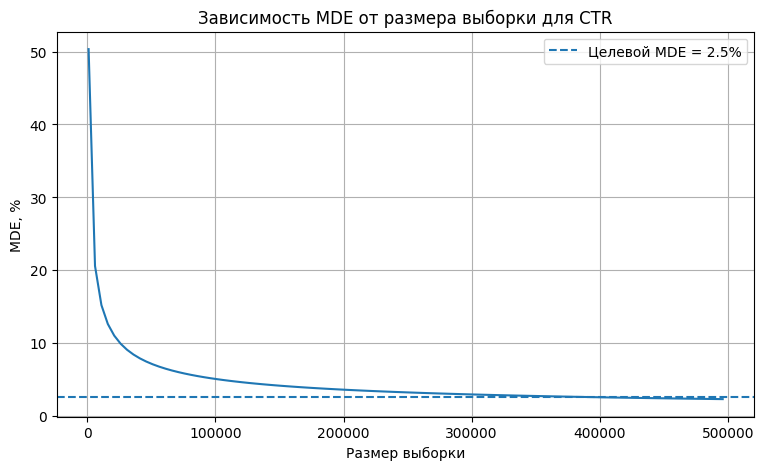

In [44]:
import matplotlib.pyplot as plt

sample_sizes = np.arange(1000, 500001, 5000)
mde_values = []

for n in sample_sizes:
    _, mde_rel = get_MDE(mu_ctr, std_ctr, sample_size=n)
    mde_values.append(mde_rel)

plt.figure(figsize=(9, 5))
plt.plot(sample_sizes, mde_values)

plt.axhline(2.5, linestyle='--', label='Целевой MDE = 2.5%')

plt.xlabel('Размер выборки')
plt.ylabel('MDE, %')
plt.title('Зависимость MDE от размера выборки для CTR')
plt.legend()
plt.grid()

plt.show()

**Вывод по размеру выборки**
При базовом CTR контрольной группы 20% для обнаружения относительного изменения на 2,5% требуется выборка около 406 000 пользователей.

По условию эксперимента выборка должна составлять не более 20% активной аудитории. Общий размер активной аудитории в предоставленных данных не указан, поэтому проверить выполнение этого ограничения напрямую невозможно. Для выборки 406 000 пользователей общая активная аудитория должна составлять не менее 2 030 000 пользователей. Если фактическая аудитория меньше, необходимо пересмотреть допустимый MDE или размер выборки.